# Task 1: Air Quality Forecasting — Model Results & Analysis
**Target:** one-hour-ahead `CO(GT)`  
**Model:** Random Forest Regressor  
**Split:** chronological 80% train / 20% test

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
DATA_PATH="/mnt/data/AirQualityUCI_submission.csv"
df=pd.read_csv(DATA_PATH,sep=None,engine="python")
df["Datetime"]=pd.to_datetime(df["Date"].astype(str)+" "+df["Time"].astype(str))
df=df.sort_values("Datetime").reset_index(drop=True)
num=df.select_dtypes(include=np.number).columns
df[num]=df[num].replace(-200,np.nan).ffill()

df["hour"]=df["Datetime"].dt.hour
df["day_of_week"]=df["Datetime"].dt.dayofweek
df["month"]=df["Datetime"].dt.month
df["is_weekend"]=(df["day_of_week"]>=5).astype(int)
df["target_next_CO"]=df["CO(GT)"].shift(-1)

lag_cols=["CO(GT)","NOx(GT)","NO2(GT)","C6H6(GT)","T","RH","AH"]
for c in lag_cols:
    df[f"{c}_lag1"]=df[c].shift(1)
    df[f"{c}_lag3"]=df[c].shift(3)
    df[f"{c}_lag24"]=df[c].shift(24)
for c in ["CO(GT)","NOx(GT)","NO2(GT)","C6H6(GT)"]:
    df[f"{c}_roll3"]=df[c].shift(1).rolling(3).mean()
    df[f"{c}_roll24"]=df[c].shift(1).rolling(24).mean()

feature_cols=[c for c in df.columns if c not in ["Date","Time","Datetime","target_next_CO"]]
model_df=df.dropna(subset=feature_cols+["target_next_CO"]).copy()
split_idx=int(len(model_df)*0.80)
train=model_df.iloc[:split_idx]; test=model_df.iloc[split_idx:]
X_train,y_train=train[feature_cols],train["target_next_CO"]
X_test,y_test=test[feature_cols],test["target_next_CO"]

model=RandomForestRegressor(n_estimators=200,max_depth=18,min_samples_leaf=2,random_state=42,n_jobs=-1)
model.fit(X_train,y_train)
pred=model.predict(X_test)

mae=mean_absolute_error(y_test,pred); mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse); r2=r2_score(y_test,pred)
results=pd.DataFrame({"Metric":["MAE","MSE","RMSE","R²"],"Value":[mae,mse,rmse,r2]})
display(results.round(4))
print("Training rows:",len(train),"Testing rows:",len(test))
print("Training:",train["Datetime"].min(),"to",train["Datetime"].max())
print("Testing:",test["Datetime"].min(),"to",test["Datetime"].max())

,Metric,Value
0,MAE,0.4439
1,MSE,0.4241
2,RMSE,0.6513
3,R²,0.7764


Training rows: 7465 Testing rows: 1867
Training: 2004-03-11 18:00:00 to 2005-01-16 18:00:00
Testing: 2005-01-16 19:00:00 to 2005-04-04 13:00:00


## Actual vs predicted and error analysis

,Datetime,target_next_CO,Prediction,Error,Absolute_Error
7489,2005-01-16 19:00:00,2.2,2.790,-0.590,0.590
7490,2005-01-16 20:00:00,1.5,2.332,-0.832,0.832
7491,2005-01-16 21:00:00,1.2,1.595,-0.395,0.395
7492,2005-01-16 22:00:00,1.5,1.015,0.485,0.485
7493,2005-01-16 23:00:00,1.4,1.613,-0.213,0.213
7494,2005-01-17 00:00:00,1.2,1.031,0.169,0.169
7495,2005-01-17 01:00:00,1.0,1.014,-0.014,0.014
7496,2005-01-17 02:00:00,0.6,0.863,-0.263,0.263
7497,2005-01-17 03:00:00,0.7,0.504,0.196,0.196
7498,2005-01-17 04:00:00,0.5,0.629,-0.129,0.129


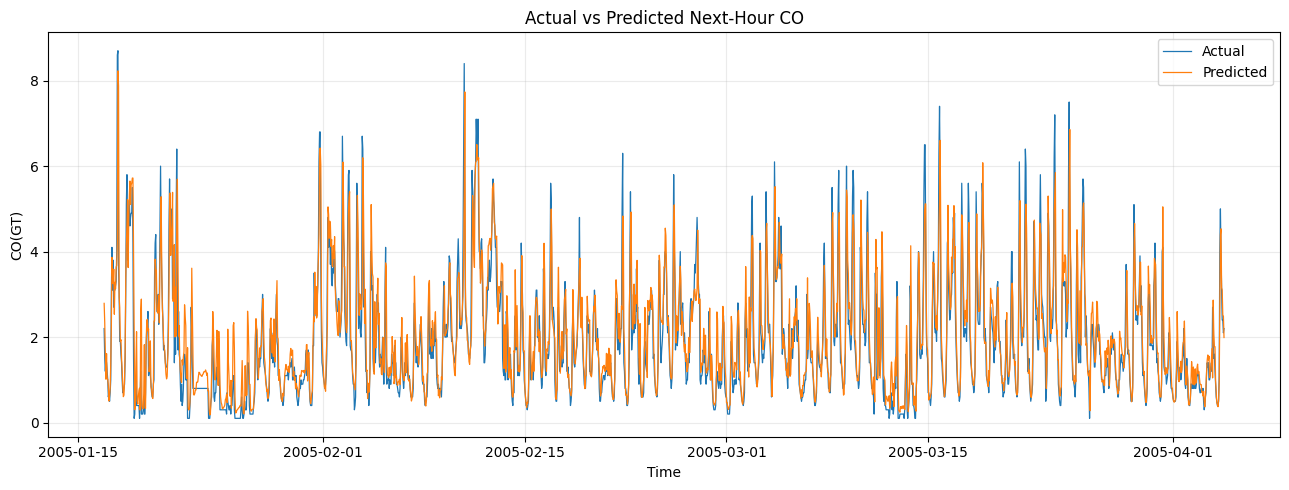

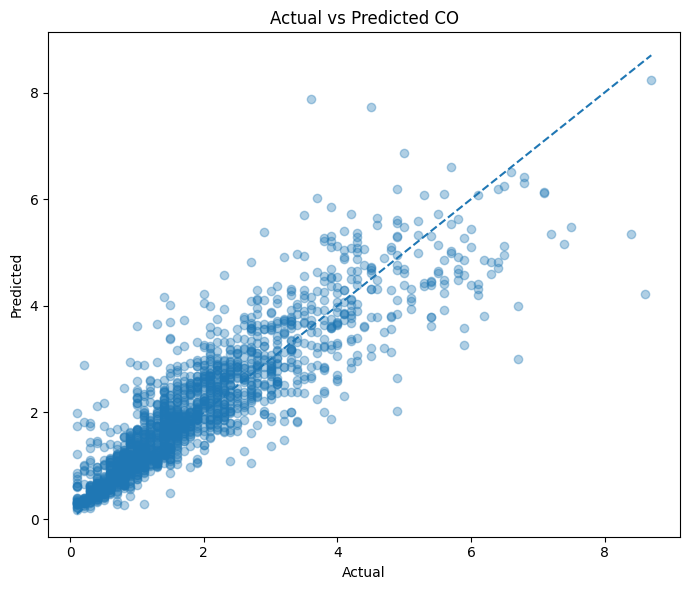

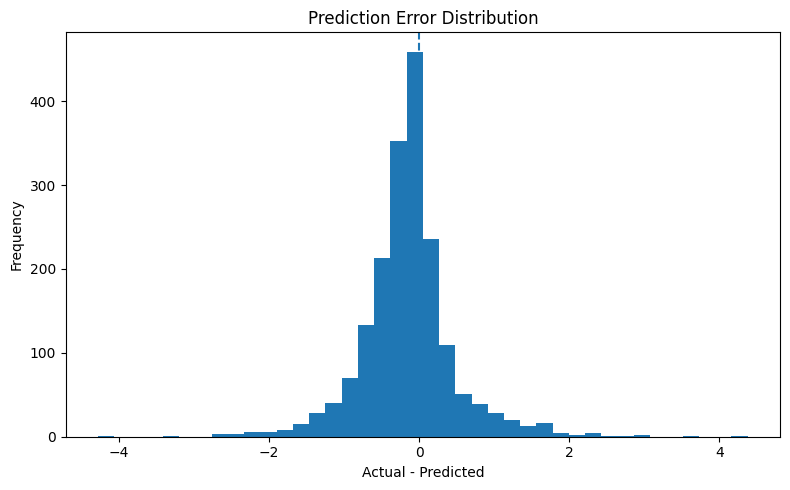

,count,mean,median,max
Actual_Quartile,,,,
"(0.099, 0.9]",502,0.2651,0.1713,2.6895
"(0.9, 1.5]",455,0.3782,0.2290,2.7616
"(1.5, 2.5]",450,0.4260,0.3232,2.2849
"(2.5, 8.7]",460,0.7213,0.5639,4.3739


In [2]:
pred_df=test[["Datetime","target_next_CO"]].copy()
pred_df["Prediction"]=pred
pred_df["Error"]=pred_df["target_next_CO"]-pred_df["Prediction"]
pred_df["Absolute_Error"]=pred_df["Error"].abs()
display(pred_df.head(15).round(3))

fig,ax=plt.subplots(figsize=(13,5))
ax.plot(pred_df["Datetime"],pred_df["target_next_CO"],label="Actual",linewidth=0.9)
ax.plot(pred_df["Datetime"],pred_df["Prediction"],label="Predicted",linewidth=0.9)
ax.set_title("Actual vs Predicted Next-Hour CO"); ax.set_xlabel("Time"); ax.set_ylabel("CO(GT)")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(7,6))
ax.scatter(pred_df["target_next_CO"],pred_df["Prediction"],alpha=0.35)
lims=[min(pred_df["target_next_CO"].min(),pred_df["Prediction"].min()),max(pred_df["target_next_CO"].max(),pred_df["Prediction"].max())]
ax.plot(lims,lims,linestyle="--")
ax.set_title("Actual vs Predicted CO"); ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(8,5))
ax.hist(pred_df["Error"],bins=40); ax.axvline(0,linestyle="--")
ax.set_title("Prediction Error Distribution"); ax.set_xlabel("Actual - Predicted"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

pred_df["Actual_Quartile"]=pd.qcut(pred_df["target_next_CO"],q=4,duplicates="drop")
display(pred_df.groupby("Actual_Quartile",observed=True)["Absolute_Error"].agg(["count","mean","median","max"]).round(4))

## Feature importance

,Importance
CO(GT),0.7701
hour,0.0275
CO(GT)_lag1,0.0150
CO(GT)_roll3,0.0139
PT08.S2(NMHC),0.0101
C6H6(GT)_lag1,0.0095
PT08.S1(CO),0.0094
C6H6(GT),0.0093
NOx(GT),0.0071
NO2(GT)_lag3,0.0062


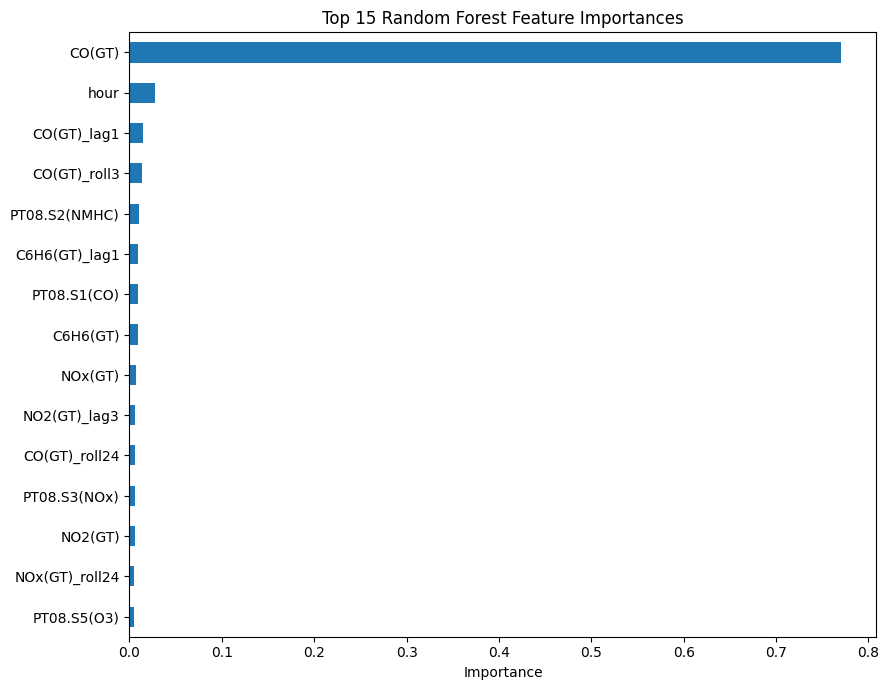

In [3]:
importance=pd.Series(model.feature_importances_,index=feature_cols).sort_values(ascending=False)
display(importance.head(20).to_frame("Importance").round(4))
fig,ax=plt.subplots(figsize=(9,7))
importance.head(15).sort_values().plot(kind="barh",ax=ax)
ax.set_title("Top 15 Random Forest Feature Importances"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

## Data leakage controls
- Chronological split: the final 20% is held out as future test data.
- The target is exactly one hour ahead.
- Lag variables use earlier observations only.
- Rolling variables are shifted before the rolling calculation.
- Missing values are forward-filled only.
- No random train/test shuffling is used.

## 5–7 Key findings
1. **Temporal dependence is important:** recent CO measurements and lag/rolling features provide useful information for one-hour-ahead forecasting.
2. **CO varies substantially over time:** the series contains pronounced short-term changes rather than a constant level.
3. **Time-of-day contributes information:** average CO differs across hours, supporting hour-based features.
4. **Pollutants are related:** other pollutant measurements provide additional predictive information.
5. **The model captures nonlinear relationships:** Random Forest can represent interactions among pollutant history, meteorological and calendar variables.
6. **Extreme observations are harder to predict:** larger absolute errors can occur for unusual/high concentration periods.
7. **The evaluation is forecasting-oriented:** chronological splitting and causal features make the test assessment more realistic than random splitting.

## 2–3 Limitations
1. **Missing-data treatment:** forward fill can carry an old measurement through a long missing interval.
2. **Model limitation:** Random Forest does not explicitly model sequential dynamics as dedicated time-series/deep-learning models do.
3. **Validation limitation:** only one chronological holdout and one forecast horizon were evaluated.

## Possible improvement for future work
Compare Random Forest with gradient boosting and dedicated time-series/deep-learning models, use rolling-origin cross-validation and systematic hyperparameter tuning, and evaluate multiple horizons such as 1-hour, 6-hour and 24-hour ahead. External variables such as traffic and weather forecasts could also be incorporated where available.

## Conclusion
The pipeline provides a leakage-aware one-hour-ahead CO forecasting workflow using the supplied UCI Air Quality dataset. It combines preprocessing, temporal feature engineering, chronological validation, Random Forest regression, standard regression metrics, error analysis and feature-importance analysis.